In [1]:
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
import pandas as pd
import ast
from pathlib import Path
from typing import Optional, List, Tuple, Dict, Any
from obspy.signal.filter import envelope
from enveloc.core import XCOR
from obspy.clients.fdsn import Client
from obspy.core.util import AttribDict
import numpy as np
from obspy import Stream
import matplotlib.pyplot as plt
import os
import obspy
import shutil
from obspy import Stream

In [2]:
def conv_to_datetime(df):
    new_df = []
    for i in range(len(df)):
        year = int(df[i].split('_')[0])
        month = int(df[i].split('_')[1])
        day = int(df[i].split('_')[2].split(' ')[0])
        hour = int(df[i].split('_')[2].split(' ')[1][0:2])
        minute = int(df[i].split('_')[2].split(' ')[1][2:4])
        second = int(df[i].split('_')[2].split(' ')[1][4:])
        new_df.append(obspy.UTCDateTime(year, month, day, hour, minute, second))
        
    return np.array(new_df)

In [3]:
client = Client('IRIS')
mt_rainier_cat = pd.read_csv('../src/mount_rainier_events_from_esec.txt', sep = '|')

In [4]:
mt_rainier_cat['starttime'] = conv_to_datetime(mt_rainier_cat['starttime'])
mt_rainier_cat['endtime'] = conv_to_datetime(mt_rainier_cat['endtime'])

In [5]:
pd.set_option('display.max_columns', None)
mt_rainier_cat

,areaSource,areaSourceHigh,areaSourceLow,areaTotal,associationId,datlocation,depth,endtime,eventid,h,hHigh,hLow,hfall,hfall_high,hfall_low,l,lHigh,lLow,latitude,locuncertKm,longitude,lppotential,mass,massHigh,massLow,maxdistvhfKm,maxdistvhfReached,maxdisthfKm,maxdisthfReached,maxdistipKm,maxdistipReached,maxdistlpKm,maxdistlpReached,maxdistinfraKm,maxdistinfraReached,infraDetected,name,otherdataquality1to5,peakDischarge,peakDischargeLow,peakDischargeHigh,peakFlowheight,peakFlowheightLow,peakFlowheightHigh,starttime,sources,toeLat,toeLon,topLat,topLon,upstreamDrainarea,type,subtype,volume,volumeHigh,volumeLow
0,NaN,NaN,NaN,NaN,120,IRIS,NaN,2011-07-06T22:25:35.000000Z,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46.84300,0.20,-121.75000,0,NaN,NaN,NaN,NaN,NaN,100.0,True,NaN,NaN,0.0,NaN,NaN,NaN,NaN,Nisqually 10,4,NaN,NaN,NaN,NaN,NaN,NaN,2011-07-06T22:23:27.000000Z,"Allstadt, Kate E., McVey, Brennah G., and Malo...",46.82050,-121.73790,46.84300,-121.75000,NaN,"rock fall, rock and ice avalanche",Rock/ice/debris avalanches and slides,71000.0,100000.0,52000.0
1,NaN,NaN,NaN,NaN,122,IRIS,NaN,1989-08-16T17:15:09.000000Z,122,2300.0,NaN,NaN,NaN,NaN,NaN,7800.0,NaN,NaN,46.87460,0.50,-121.75370,0,NaN,NaN,NaN,NaN,NaN,181.0,False,NaN,NaN,0.0,NaN,NaN,NaN,NaN,"Russell Cliff 2, Mount Rainier",3,NaN,NaN,NaN,NaN,NaN,NaN,1989-08-16T17:14:09.000000Z,"Allstadt, Kate E., McVey, Brennah G., and Malo...",NaN,NaN,NaN,NaN,NaN,rock fall,Rock/debris falls,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,82,IRIS,NaN,2014-02-25T13:43:28.000000Z,82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46.83720,0.20,-121.75070,0,NaN,NaN,NaN,NaN,NaN,15.0,True,NaN,NaN,0.0,NaN,NaN,NaN,NaN,Mount Rainier,3,NaN,NaN,NaN,NaN,NaN,NaN,2014-02-25T13:39:24.000000Z,"Allstadt, Kate E., McVey, Brennah G., and Malo...",NaN,NaN,NaN,NaN,NaN,ice avalanche,Rock/ice/debris avalanches and slides,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,118,IRIS,NaN,2011-06-29T03:43:04.000000Z,118,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46.84300,0.20,-121.75000,0,NaN,NaN,NaN,NaN,NaN,13.0,True,NaN,NaN,0.0,NaN,NaN,NaN,NaN,Nisqually 6,4,NaN,NaN,NaN,NaN,NaN,NaN,2011-06-29T03:42:04.000000Z,"Allstadt, Kate E., McVey, Brennah G., and Malo...",46.82050,-121.73790,46.84300,-121.75000,NaN,"rock fall, rock and ice avalanche",Rock/ice/debris avalanches and slides,12000.0,17000.0,8600.0
4,50000.0,75000.0,45000.0,550000.0,25,IRIS,NaN,2011-06-25T15:21:53.000000Z,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46.84300,0.20,-121.75000,0,NaN,NaN,NaN,NaN,NaN,133.0,True,NaN,NaN,0.0,NaN,NaN,NaN,NaN,Nisqually 2,4,NaN,NaN,NaN,NaN,NaN,NaN,2011-06-25T15:20:42.000000Z,"Allstadt, Kate E., McVey, Brennah G., and Malo...",46.82050,-121.73790,46.84300,-121.75000,NaN,"rock fall, rock and ice avalanche",Rock/ice/debris avalanches and slides,37000.0,53000.0,27000.0
5,NaN,NaN,NaN,NaN,335,IRIS,NaN,2023-12-10T19:08:08.000000Z,335,1300.0,1500.0,900.0,NaN,NaN,NaN,2900.0,3200.0,2700.0,46.86120,0.00,-121.73900,0,NaN,NaN,NaN,NaN,NaN,78.0,True,NaN,NaN,0.0,NaN,9.0,True,True,"Emmons Glacier, Mount Rainier",4,NaN,NaN,NaN,NaN,NaN,NaN,2023-12-10T19:04:45.000000Z,"Collins, E.A., Allstadt, K.E., Groult, C., Hib...",46.87390,-121.70690,46.86120,-121.73900,NaN,snow avalanche,Snow avalanches,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,121,IRIS,NaN,1989-08-16T17:07:08.000000Z,121,2300.0,NaN,NaN,NaN,NaN,NaN,7800.0,NaN,NaN,46.87460,0.50,-121.75370,0,NaN,NaN,NaN,NaN,NaN,91.0,False,NaN,NaN,0.0,NaN,NaN,NaN,NaN,"Russell Cliff 1, Mount Rainier",3,NaN,NaN,NaN,NaN,NaN,NaN,1989-08-16T17:06:19.000000Z,"Allstadt, Kate E., McVey, Brennah G., and Malo...",NaN,NaN,NaN,NaN,NaN,rock fall,Rock/debris falls,NaN,NaN,NaN
7,NaN,NaN,NaN,200000.0,179,IRIS,NaN,2021-03-11T22:59:19.000000Z,179,600.0,NaN,NaN,NaN,NaN,NaN,1200.0,NaN,NaN,46.85850,0.35,-121.78570,0,NaN,NaN,NaN,NaN,NaN,12.0,True,NaN,NaN,0.0,NaN,0.0,NaN,False,"Sunset Amphitheater, Mount Rainier",2,NaN,NaN,NaN,NaN,NaN,NaN,2021-03-11T22:58:14.000000Z,"Collins, E.A., Allstadt, K.E., Groult, C., Hib...",46.85350,-121.79910,46.86100,-121.78720,NaN,snow avalanche,Snow avalanches,NaN,NaN,NaN
8,NaN,NaN,NaN

In [6]:
ev_lats = mt_rainier_cat['latitude']
ev_lons = mt_rainier_cat['longitude']
ev_starttimes = mt_rainier_cat['starttime']
ev_endtimes = mt_rainier_cat['endtime']
ev_types = mt_rainier_cat['type']
ev_subtypes = mt_rainier_cat['subtype']
ev_evids = mt_rainier_cat['eventid']
ev_locuncerts = mt_rainier_cat['locuncertKm']
ev_dataqualities = mt_rainier_cat['otherdataquality1to5']
ev_names = mt_rainier_cat['name']


In [7]:
from obspy.clients.fdsn import Client
from obspy import UTCDateTime

# Pick the FDSN client you normally use.
# Try "IRIS" (EarthScope), or a regional one if you have it.
client = Client("IRIS")

north, east, south, west = 47.1241, -121.355, 46.617, -122.1455

# Infrasound/pressure channels: instrument code "D"
inv = client.get_stations(
    minlatitude=south, maxlatitude=north,
    minlongitude=west, maxlongitude=east,
    channel="*DF",   # pressure channels (e.g., BDF, HDF, LDF)
    level="channel"
)

print(inv)  # inspect what networks/stations/channels you got


Inventory created at 2026-02-16T22:15:34.757800Z
	Created by: IRIS WEB SERVICE: fdsnws-station | version: 1.1.52
		    http://service.iris.edu/fdsnws/station/1/query?channel=%2ADF&minlat...
	Sending institution: IRIS-DMC (IRIS-DMC)
	Contains:
		Networks (4):
			C0, CC, UW, ZD
		Stations (43):
			C0.PALI (Palisades)
			CC.ARAT (Mount Ararat)
			CC.COPP (COPP)
			CC.CRBN (Carbon River Ranger Station)
			CC.CRYS (Crystal Mountain)
			CC.GTWY (Gateway Entrance Station)
			CC.KAUT (Kautz Creek Helibase)
			CC.LONE (Lonesome Lake)
			CC.LONR (Lonesome Lake Unique)
			CC.MILD (Mildred Point)
			CC.MIRR (Mirror Lakes Temporary Infrasound Array)
			CC.OPCH (Ohanapecosh Administrative Area)
			CC.PALI (Palisades)
			CC.PARA (Paradise Precip Tower)
			CC.PR01 (Puyallup River 01)
			CC.PR02 (Puyallup River 02)
			CC.PR03 (Puyallup River 03)
			CC.PR04 (Puyallup River 04)
			CC.PR05 (Puyallup River 05)
			CC.SIFT (Swift Creek)
			CC.STYX (STYX, Puyallup River, WA, USA)
			CC.SUNT (Sun Top)
			CC.TA

In [8]:
def list_infrasound_channels(inv):
    rows = []
    for net in inv:
        for sta in net:
            for cha in sta:
                code = cha.code  # e.g., "BDF"
                if len(code) == 3 and code[1] == "D":
                    loc = cha.location_code or ""
                    rows.append((net.code, sta.code, loc, code, cha.latitude, cha.longitude, cha.elevation))
    return rows

infra_rows = list_infrasound_channels(inv)
print(f"Found {len(infra_rows)} infrasound channels in box.")
print(infra_rows[:5])


Found 311 infrasound channels in box.
[('C0', 'PALI', '01', 'BDF', 47.0777, -121.7105, 1420.5), ('C0', 'PALI', '02', 'BDF', 47.0777, -121.7105, 1420.5), ('C0', 'PALI', '03', 'BDF', 47.0777, -121.7105, 1420.5), ('CC', 'ARAT', '01', 'BDF', 46.788986, -121.852905, 1822.4), ('CC', 'ARAT', '01', 'BDF', 46.788986, -121.852905, 1822.4)]


In [9]:
import matplotlib.pyplot as plt
from obspy import Stream


import numpy as np

def normalize_stream_by_max(st):
    """
    Normalize each trace by its absolute maximum amplitude.
    """
    st = st.copy()
    for tr in st:
        maxamp = np.max(np.abs(tr.data))
        if maxamp > 0:
            tr.data = tr.data / maxamp
    return st




def preprocess_infrasound(st, inv=None, taper=0.05, freqmin= 1, freqmax=10.0):
    """
    Simple, safe preprocessing for infrasound:
    - merge gaps
    - detrend
    - taper
    - bandpass
    Optionally remove instrument response if inventory provided.
    """
    if len(st) == 0:
        return st

    st = st.copy()
    st.merge(method=1, fill_value="interpolate")  # handle small gaps
    st.detrend("linear")
    st.detrend("demean")
    st.taper(max_percentage=taper)

    # Optional response removal (only if you have correct response metadata)
    # If you do remove_response, choose output="PA" if the response supports it.
    # if inv is not None:
    #     st.remove_response(inventory=inv, output="PA", water_level=60)

    st.filter("bandpass", freqmin=freqmin, freqmax=freqmax, corners=4, zerophase=True)
    return st

def plot_event_infrasound(mt_rainier_cat, event_idx, inv, client,
                          pad_before=60, pad_after=60,
                          freqmin=0.5, freqmax=10.0,
                          max_traces= 2e+10):
    """
    mt_rainier_cat: must let you access start/end as UTCDateTime or ISO string
    event_idx: index of event row
    inv: station inventory returned by get_stations (level="channel")
    """
    # ---- get start/end from your catalog row ----
    row = mt_rainier_cat.iloc[event_idx]  # if it's a pandas DF
    t0 = row["starttime"]
    t1 = row["endtime"]

    # Make sure UTCDateTime
    if not isinstance(t0, UTCDateTime):
        t0 = UTCDateTime(t0)
    if not isinstance(t1, UTCDateTime):
        t1 = UTCDateTime(t1)

    tstart = t0 - pad_before
    tend   = t1 + pad_after

    # ---- gather infrasound traces ----
    st_all = Stream()
    picked = 0

    for net in inv:
        for sta in net:
            for cha in sta:
                code = cha.code
                if len(code) == 3 and code[1] != "D":
                    continue
                loc = cha.location_code or ""

                try:
                    st = client.get_waveforms(
                        network=net.code, station=sta.code, location=loc, channel=code,
                        starttime=tstart, endtime=tend, attach_response=False
                    )
                except Exception:
                    continue

                if len(st) == 0:
                    continue

                st = preprocess_infrasound(st, inv=None, freqmin=freqmin, freqmax=freqmax)
                st_all += st
                picked += len(st)
                if picked >= max_traces:
                    break
            if picked >= max_traces:
                break
        if picked >= max_traces:
            break

    if len(st_all) == 0:
        print(f"No infrasound data found for event {event_idx} in window {tstart} - {tend}")
        return None

    # ---- plot ----
    # ObsPy's built-in plotting is quick; it makes a stacked plot per trace
    # Normalize each trace individually
    st_norm = normalize_stream_by_max(st_all)

    st_norm.plot(
        type="normal",
        size=(1200, 800),
        title=f"Event {event_idx}: {t0} to {t1} "
              f"(normalized, bandpass {freqmin}-{freqmax} Hz)"
    )

    return st_all


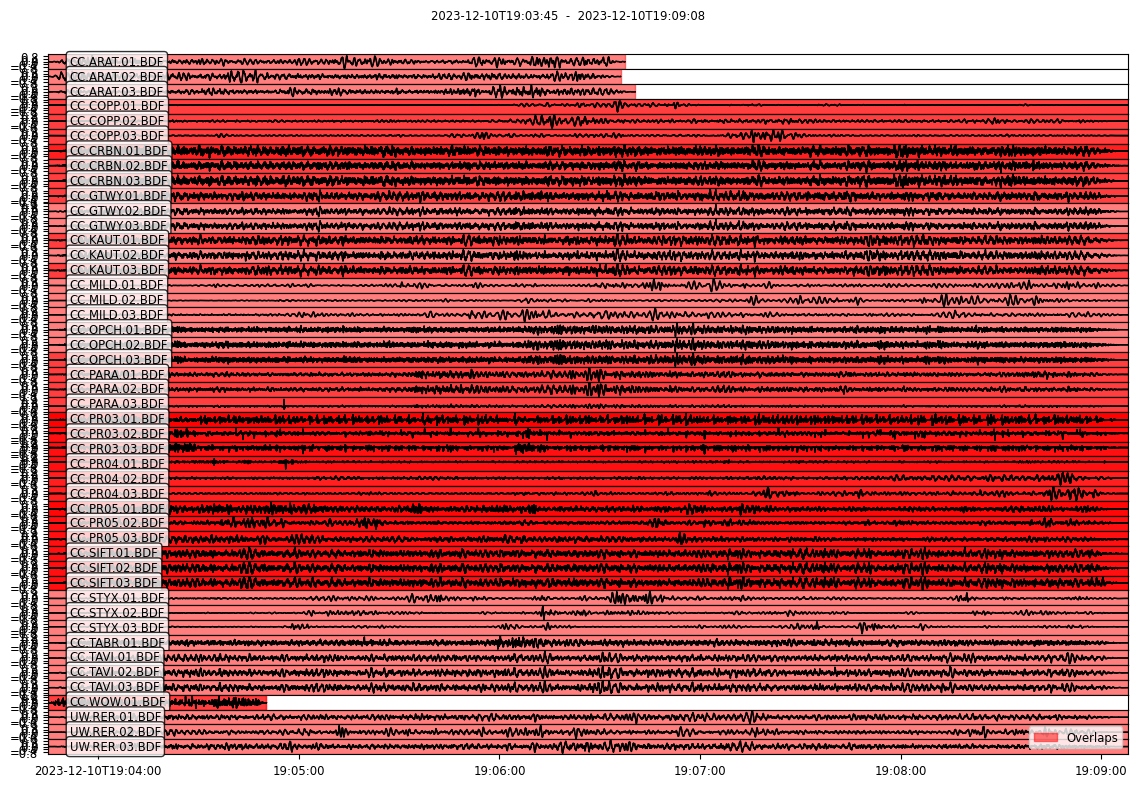

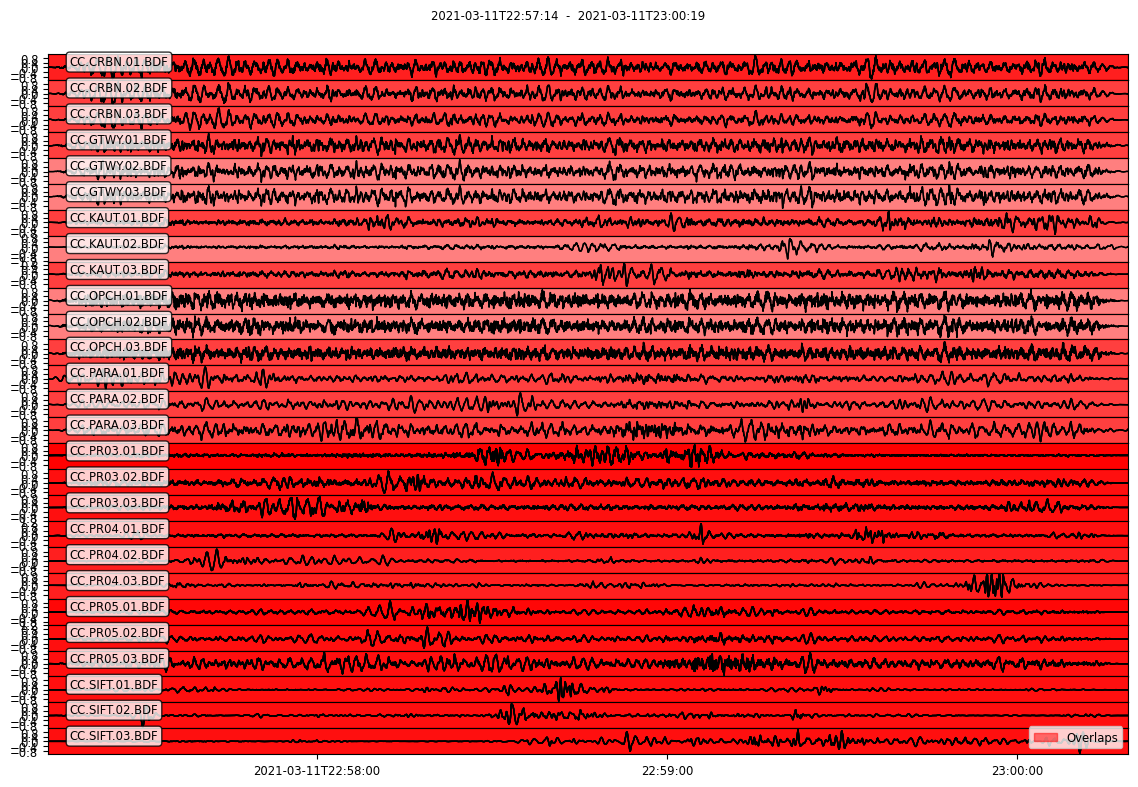

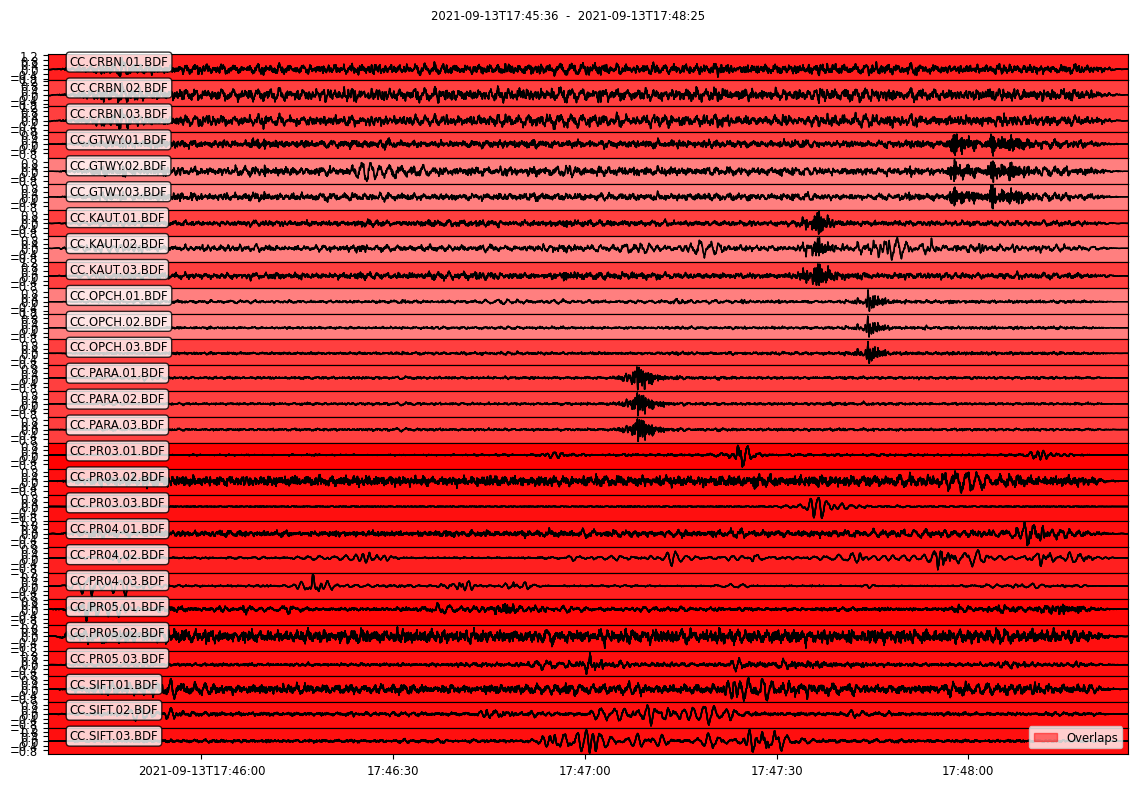

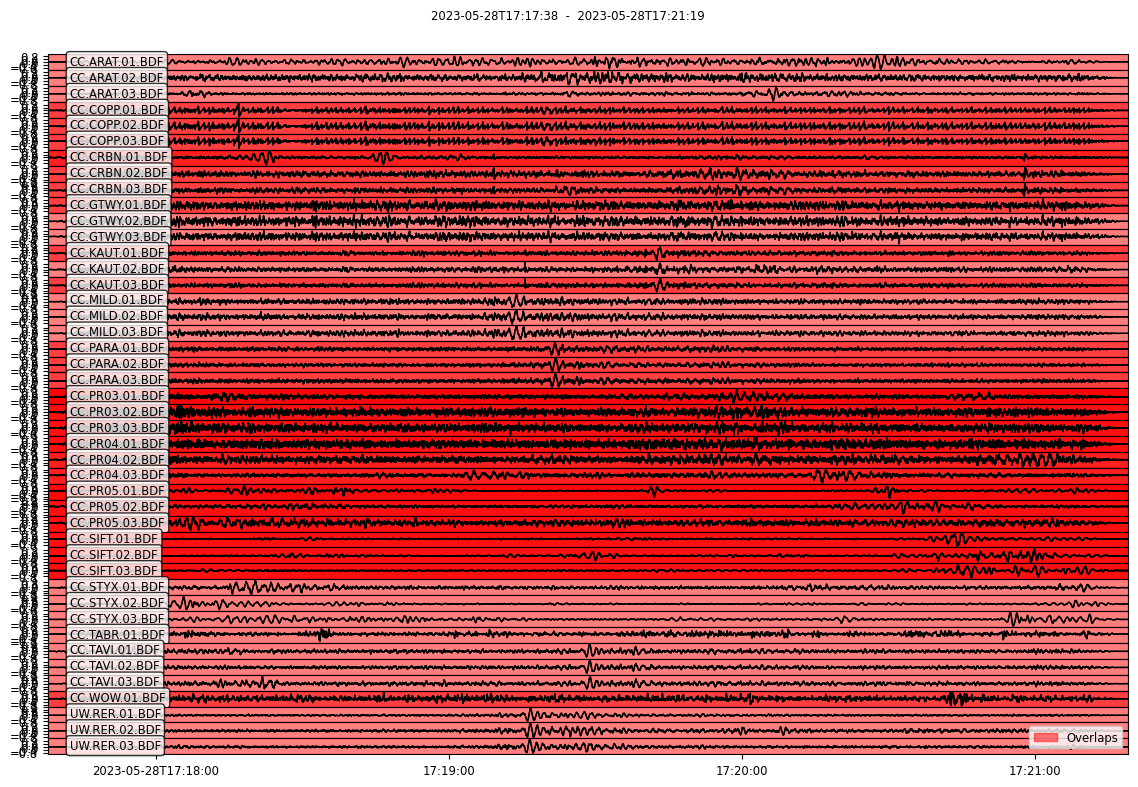

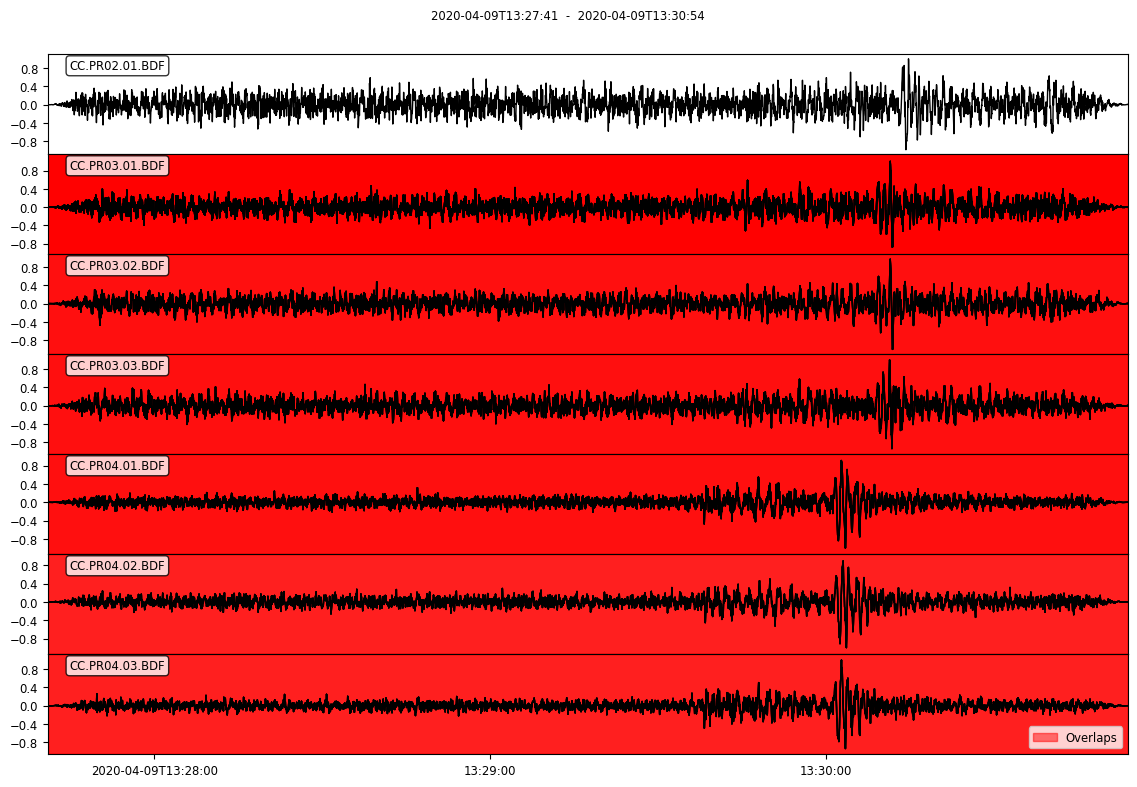

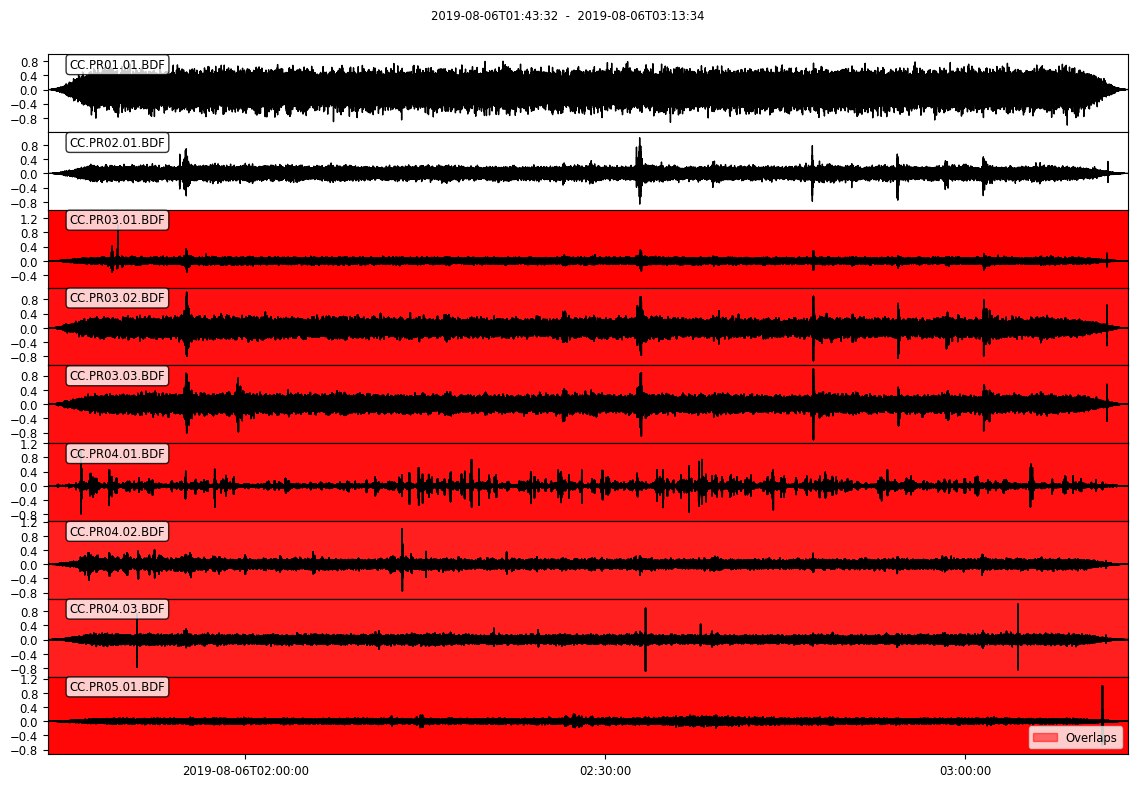

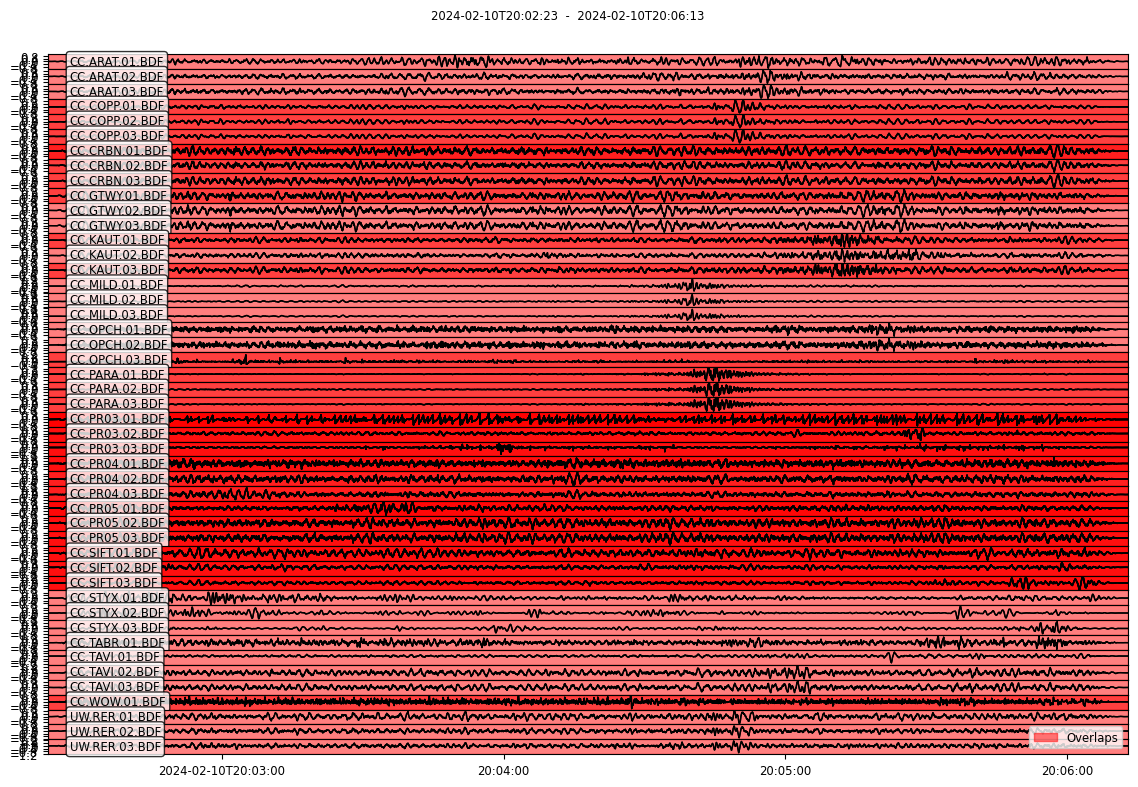

No infrasound data found for event 7 in window 2019-09-27T00:42:20.000000Z - 2019-09-27T01:30:22.000000Z


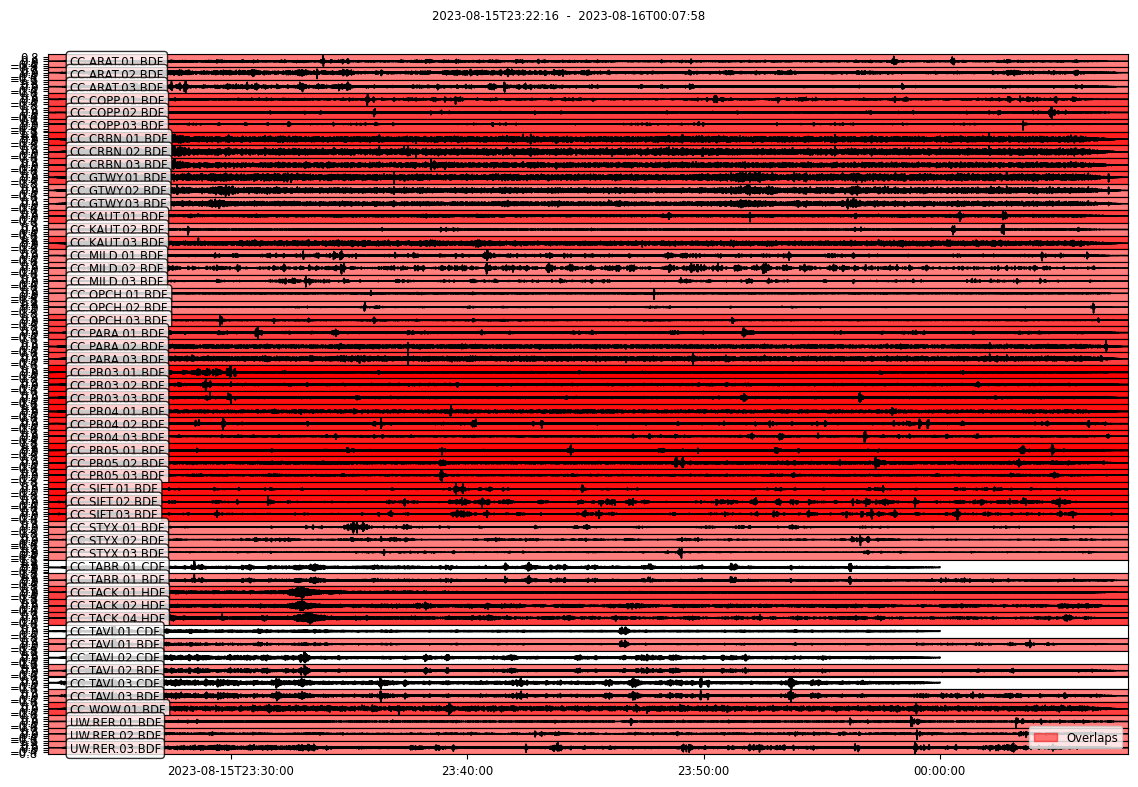

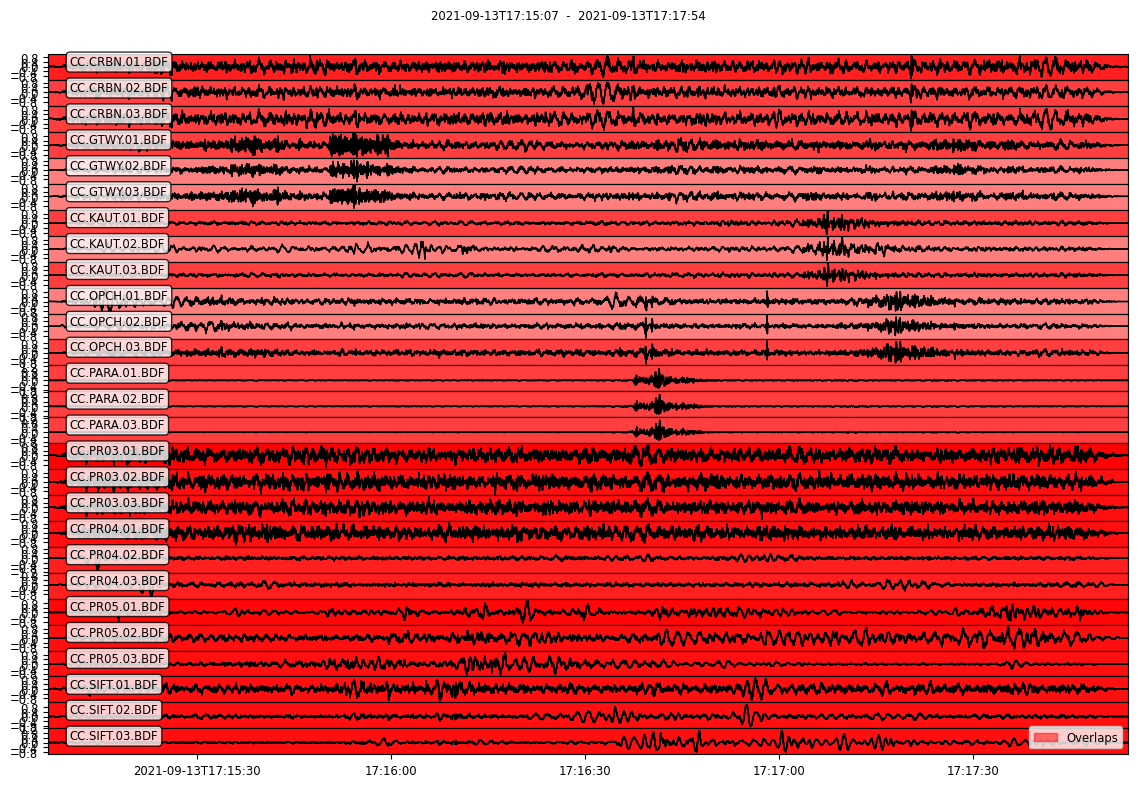

KeyboardInterrupt: 

KeyboardInterrupt: 

In [10]:
from obspy import UTCDateTime

cutoff = UTCDateTime("2019-01-01T00:00:00")

mt_rainier_cat_2019 = mt_rainier_cat[
    mt_rainier_cat["starttime"].apply(lambda t: t >= cutoff)
]


# Example: plot first 5 events
for i in range(len(mt_rainier_cat_2019)):
    st_all = plot_event_infrasound(mt_rainier_cat_2019, i, inv, client)


In [ ]:
mt_rainier_cat_2019

In [ ]:
print(st_all.__str__(extended=True))

In [ ]:
from obspy import Stream

def merge_overlaps_by_id(st, fill="interpolate"):
    out = Stream()
    for tr_id in sorted({tr.id for tr in st}):
        s = st.select(id=tr_id).copy()
        s.sort(keys=["starttime"])
        # This merges overlaps/gaps into as few traces as possible
        s.merge(method=1, fill_value=fill)  # method=1 is “interpolate small gaps”
        out += s
    return out




def drop_exact_clones(st: Stream) -> Stream:
    """
    Drop exact duplicate traces by id + start/end + npts.
    Uses only primitive types in the key to avoid hashing issues.
    """
    seen = set()
    out = Stream()

    for tr in st:
        # Convert UTCDateTime -> nanoseconds integer (safe + hashable)
        s_ns = int(tr.stats.starttime.ns)
        e_ns = int(tr.stats.endtime.ns)

        key = (str(tr.id), s_ns, e_ns, int(tr.stats.npts))

        if key not in seen:
            out += tr
            seen.add(key)

    return out



from collections import defaultdict

def group_by_array(st):
    arrays = defaultdict(Stream)
    for tr in st:
        net, sta, loc, cha = tr.id.split(".")
        arrays[(net, sta)] += tr
    return arrays


from obspy.core.util import AttribDict

def attach_coordinates_from_inventory(st, inv):
    """
    Attach per-trace coordinates using a channel-level Inventory.
    """
    for tr in st:
        net = tr.stats.network
        sta = tr.stats.station
        loc = tr.stats.location or ""
        cha = tr.stats.channel

        sel = inv.select(network=net, station=sta, location=loc, channel=cha)
        if len(sel.networks) == 0 or len(sel.networks[0].stations) == 0 or len(sel.networks[0].stations[0].channels) == 0:
            # no match
            continue

        ch = sel.networks[0].stations[0].channels[0]
        tr.stats.coordinates = AttribDict({
            "latitude": float(ch.latitude),
            "longitude": float(ch.longitude),
            "elevation": float(ch.elevation),
        })
    return st



from obspy.core.util import AttribDict

def attach_coordinates_from_inventory(st, inv, strict=True):
    missing = []
    for tr in st:
        net = tr.stats.network
        sta = tr.stats.station
        loc = tr.stats.location or ""
        cha = tr.stats.channel

        sel = inv.select(network=net, station=sta, location=loc, channel=cha)
        ok = (len(sel.networks) and len(sel.networks[0].stations) and len(sel.networks[0].stations[0].channels))
        if not ok:
            missing.append(tr.id)
            if strict:
                continue  # collect all missing first
            else:
                continue

        ch = sel.networks[0].stations[0].channels[0]
        tr.stats.coordinates = AttribDict(
            latitude=float(ch.latitude),
            longitude=float(ch.longitude),
            elevation=float(ch.elevation),
        )

    if strict and missing:
        raise ValueError(f"Missing channel metadata for {len(missing)} traces. Examples: {missing[:20]}")

    return st



In [ ]:
st = st_all.copy()
st = merge_overlaps_by_id(st, fill = "interpolate")
st = drop_exact_clones(st)



## making sure that each of the elements have geographical coordinates. 

nets = sorted({tr.stats.network for tr in st})
stas = sorted({tr.stats.station for tr in st})
chas = sorted({tr.stats.channel for tr in st})
locs = sorted({tr.stats.location for tr in st})

print("networks:", nets)
print("num stations:", len(stas), "example:", stas[:10])
print("channels:", chas)
print("locations:", locs[:10])


In [ ]:
tstart= st[0].stats.starttime - 100
tend = st[0].stats.endtime + 100


from obspy import Inventory

inv_all = Inventory(networks=[], source="")

for net in nets:
    inv_net = client.get_stations(
        network=net,
        station="*",        # all stations in this network
        location="*",       # include 01/02/03 etc
        channel=",".join(chas) if len(chas) > 1 else chas[0],
        starttime=tstart,
        endtime=tend,
        level="channel"
    )
    inv_all += inv_net


In [ ]:
st_clean = attach_coordinates_from_inventory(st, inv_all, strict=True)
arrays = group_by_array(st_clean)

In [ ]:
# verify that each array has indeed distinct elements. 
for (net, sta), st_a in list(arrays.items())[:10]:
    uniq = len(set((tr.stats.coordinates.latitude, tr.stats.coordinates.longitude) for tr in st_a))
    print(net, sta, "channels:", len(st_a), "unique coords:", uniq)


In [ ]:
import os
from obspy.io.sac import SACTrace

def write_array_to_sac(st_array, outdir):
    os.makedirs(outdir, exist_ok=True)
    for tr in st_array:
        c = tr.stats.coordinates
        sac = SACTrace.from_obspy_trace(tr)
        sac.stla = float(c.latitude)
        sac.stlo = float(c.longitude)
        sac.stel = float(c.elevation)
        fn = f"{tr.id.replace('.', '_')}.SAC"
        sac.write(os.path.join(outdir, fn))


In [ ]:
arrays.keys()

In [ ]:
print("Total network-station combinations:", len(arrays))
print("Example keys:", list(arrays.keys())[:10])


In [ ]:
for (net, sta), st_array in arrays.items():
    outdir = f"fk_inputs/{net}_{sta}"
    print(f"Writing {net}.{sta} with {len(st_array)} channels")
    write_array_to_sac(st_array, outdir)


In [ ]:
!ls


In [ ]:
st = obspy.read('fk_inputs/CC_PARA/*.SAC')

In [ ]:
st.filter('bandpass', freqmin = 0.5, freqmax = 5)
st.plot()